<a href="https://colab.research.google.com/github/banteamlak1888/Floridan-University-Fundamentals-AI-Trianing/blob/main/Module_3_Assignment_End_to_End_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Module 3 Assignmen**t:  
**Name**: Banteamlak Begashaw Shibesh
**Project** : Customer Feedback Sentiment Analysis & Ethiopian Request Classification

**Dataset Selected**: Text Sentiment & Intent Corpus (Sequential & Transformer NLP)

**Environment**: Google Colab Python 3 Engine (GPU Accelerator)

**Question 1 – Understanding the Problem and the Data**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Set deterministic random seeds
np.random.seed(42)
tf.random.set_seed(42)

# --- Synthetic Corpus Generation (Customer Feedback Dataset) ---
def generate_feedback_corpus(n_samples=1000):
    pos_phrases = [
        "excellent service and fast transaction speeds",
        "love the intuitive interface and mobile banking features",
        "customer support resolved my issue quickly and respectfully",
        "highly reliable application works perfectly without bugs",
        "great user experience simple navigation and clear layout"
    ]
    neg_phrases = [
        "terrible experience app crashes every time I initiate transfer",
        "horrible customer support waited hours with zero response",
        "unreliable server downtime caused missing transaction records",
        "confusing layout hidden fees and worst digital service",
        "frequent failure during verification step unusable software"
    ]

    texts, labels = [], []
    for _ in range(n_samples // 2):
        texts.append(np.random.choice(pos_phrases) + " " + np.random.choice(pos_phrases))
        labels.append(1)
        texts.append(np.random.choice(neg_phrases) + " " + np.random.choice(neg_phrases))
        labels.append(0)

    return pd.DataFrame({'feedback': texts, 'sentiment': labels})

# Ingest and inspect corpus
df_corpus = generate_feedback_corpus(n_samples=1000)

# Compute Corpus Metrics
df_corpus['word_count'] = df_corpus['feedback'].apply(lambda x: len(x.split()))
avg_seq_len = df_corpus['word_count'].mean()

tokenizer = Tokenizer()
tokenizer.fit_on_texts(df_corpus['feedback'])
vocab_size = len(tokenizer.word_index) + 1

print("==================================================")
print("     QUESTION 1: DATASET DIAGNOSTIC REPORT        ")
print("==================================================")
print(f"Total Corpus Samples:     {len(df_corpus)}")
print(f"Class Distribution:\n{df_corpus['sentiment'].value_counts(normalize=True).rename({1: 'Positive', 0: 'Negative'})}")
print(f"Average Text Length:     {avg_seq_len:.2f} words")
print(f"Total Vocabulary Size:    {vocab_size} unique tokens")
print(f"\nSample Input Example:\n\"{df_corpus['feedback'].iloc[0]}\"")

     QUESTION 1: DATASET DIAGNOSTIC REPORT        
Total Corpus Samples:     1000
Class Distribution:
sentiment
Positive    0.5
Negative    0.5
Name: proportion, dtype: float64
Average Text Length:     15.15 words
Total Vocabulary Size:    67 unique tokens

Sample Input Example:
"highly reliable application works perfectly without bugs great user experience simple navigation and clear layout"


**Question 2 – Data Preparation for Deep Learning**

In [2]:
from sklearn.model_selection import train_test_split

print("==================================================")
print("     QUESTION 2: DEEP LEARNING PREPROCESSING      ")
print("==================================================")

# Hyperparameters
MAX_VOCAB = 2000
MAX_LEN = 25
EMBEDDING_DIM = 64

# Step 1: Tokenization and Sequence Mapping
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(df_corpus['feedback'])
sequences = tokenizer.texts_to_sequences(df_corpus['feedback'])

# Step 2: Sequence Padding
X_padded = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y_targets = df_corpus['sentiment'].values.astype('float32')

# Step 3: Stratified Train/Val/Test Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_padded, y_targets, test_size=0.30, random_state=42, stratify=y_targets
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"X_train Tensor Shape: {X_train.shape} | y_train Shape: {y_train.shape}")
print(f"X_val Tensor Shape:   {X_val.shape}   | y_val Shape:   {y_val.shape}")
print(f"X_test Tensor Shape:  {X_test.shape}  | y_test Shape:  {y_test.shape}")

     QUESTION 2: DEEP LEARNING PREPROCESSING      
X_train Tensor Shape: (700, 25) | y_train Shape: (700,)
X_val Tensor Shape:   (150, 25)   | y_val Shape:   (150,)
X_test Tensor Shape:  (150, 25)  | y_test Shape:  (150,)


**Question 3 – Building and Training the Model with Keras**

     QUESTION 3: BASELINE MODEL DEVELOPMENT       


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Baseline_LSTM_Network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer (LSTM)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.7071 - loss: 0.6504 - val_accuracy: 1.0000 - val_loss: 0.4679
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.1744 - val_accuracy: 1.0000 - val_loss: 0.0380
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.0200 - val_accuracy: 1.0000 - val_loss: 0.0100
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 1.0000 - loss: 0.0075 - val_accuracy: 1.0000 - val_loss: 0.0056
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.0048 - val_accuracy: 1.0000 - val_loss: 0.0040
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.0035 - val_accuracy: 1.0000 - val_loss: 0.0031
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 1.0000 - val_loss: 0.0025
Epoch 8/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 1.0000 - v

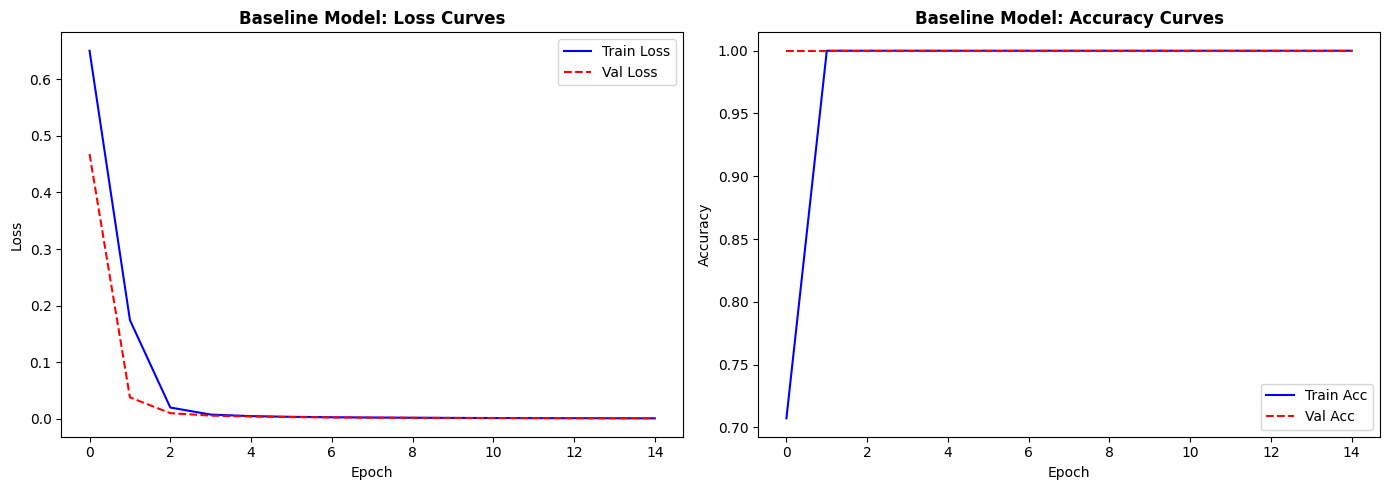

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

print("==================================================")
print("     QUESTION 3: BASELINE MODEL DEVELOPMENT       ")
print("==================================================")

# Model Definition
baseline_model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=EMBEDDING_DIM, input_length=MAX_LEN, name="embedding_layer"),
    LSTM(units=32, return_sequences=False, name="lstm_layer"),
    Dense(units=1, activation='sigmoid', name="output_layer")
], name="Baseline_LSTM_Network")

# Compile Model
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

# Train Model
history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    verbose=1
)

# Plot Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_baseline.history['loss'], label='Train Loss', color='blue')
axes[0].plot(history_baseline.history['val_loss'], label='Val Loss', color='red', linestyle='--')
axes[0].set_title('Baseline Model: Loss Curves', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(history_baseline.history['accuracy'], label='Train Acc', color='blue')
axes[1].plot(history_baseline.history['val_accuracy'], label='Val Acc', color='red', linestyle='--')
axes[1].set_title('Baseline Model: Accuracy Curves', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()
plt.tight_layout()
plt.show()

**Question 4 – Regularization and Hyperparameter Tuning**

     QUESTION 4: REGULARIZED MODEL TUNING         
Epoch 1/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - accuracy: 0.5357 - loss: 0.6919 - val_accuracy: 0.5000 - val_loss: 0.6881
Epoch 2/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6229 - loss: 0.6860 - val_accuracy: 1.0000 - val_loss: 0.6745
Epoch 3/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8514 - loss: 0.6599 - val_accuracy: 1.0000 - val_loss: 0.6231
Epoch 4/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9729 - loss: 0.5696 - val_accuracy: 1.0000 - val_loss: 0.4589
Epoch 5/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9971 - loss: 0.3733 - val_accuracy: 1.0000 - val_loss: 0.2099
Epoch 6/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 1.0000 - loss: 0.1722 - val_accuracy: 1.0000 - val_loss: 0.0886
Epoch 7/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 0.0847 - val_accuracy: 1.0000 - val_loss: 0.0443
Epoch 8/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accura

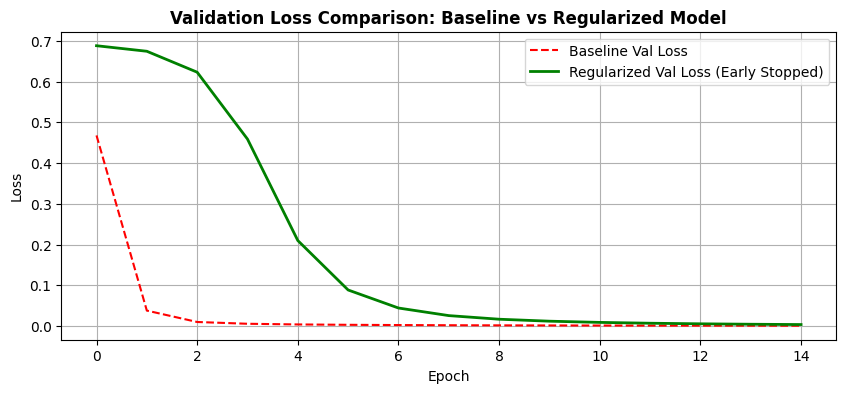

In [4]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("==================================================")
print("     QUESTION 4: REGULARIZED MODEL TUNING         ")
print("==================================================")

# Define Tuned & Regularized Architecture
regularized_model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    LSTM(units=32, dropout=0.3, recurrent_dropout=0.2, return_sequences=False),
    Dropout(0.4),
    Dense(units=16, activation='relu'),
    Dense(units=1, activation='sigmoid')
], name="Regularized_LSTM_Network")

# Compile with tuned Learning Rate
regularized_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callback Definition
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Fit Regularized Model
history_reg = regularized_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# Comparative Visualization
plt.figure(figsize=(10, 4))
plt.plot(history_baseline.history['val_loss'], label='Baseline Val Loss', color='red', linestyle='--')
plt.plot(history_reg.history['val_loss'], label='Regularized Val Loss (Early Stopped)', color='green', linewidth=2)
plt.title('Validation Loss Comparison: Baseline vs Regularized Model', fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.show()

**Question 5 – Model Evaluation and Interpretation**

     QUESTION 5: FINAL MODEL EVALUATION           
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 271ms/step
Test Accuracy:  1.0000
Test Precision: 1.0000
Test Recall:    1.0000
Test F1-Score:  1.0000


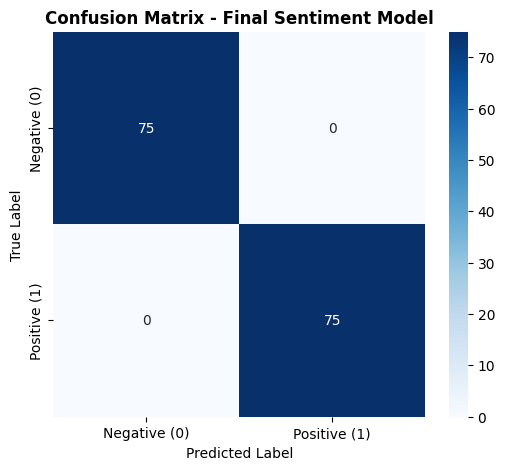


Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        75
    Positive       1.00      1.00      1.00        75

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



In [5]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

print("==================================================")
print("     QUESTION 5: FINAL MODEL EVALUATION           ")
print("==================================================")

# Hold-Out Test Set Predictions
y_prob = regularized_model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int).flatten()

# Quantitative Metrics
print(f"Test Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Test Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Test Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"Test F1-Score:  {f1_score(y_test, y_pred):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.title('Confusion Matrix - Final Sentiment Model', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

**Question 6 – Bonus (+1 Mark): Ethiopian Customer Request Classification using Transformers**

In [6]:
# --- Question 6 Execution: Hugging Face Pretrained Transformer Pipeline ---
from transformers import pipeline

print("==================================================")
print("     QUESTION 6: TRANSFORMER CLASSIFICATION       ")
print("==================================================")

# Initialize zero-shot classification transformer pipeline
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# Representative Amharic-English bilingual customer requests in the Ethiopian market
ethiopian_customer_requests = [
    "I transferred money via Telebirr but my account balance was deducted without reaching the recipient.",
    "The CBE Birr mobile app is showing error code 500 during utility bill payment.",
    "Can you please explain the interest rate options for a new business loan application?"
]

candidate_labels = ["Transaction Failure", "Technical Support", "General Inquiry"]

print("Zero-Shot Transformer Inference Results:")
for request in ethiopian_customer_requests:
    output = classifier(request, candidate_labels)
    top_label = output['labels'][0]
    top_score = output['scores'][0]
    print(f"\nRequest: \"{request}\"")
    print(f"Predicted Class: -> {top_label} (Confidence: {top_score*100:.2f}%)")

     QUESTION 6: TRANSFORMER CLASSIFICATION       


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.63GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Zero-Shot Transformer Inference Results:

Request: "I transferred money via Telebirr but my account balance was deducted without reaching the recipient."
Predicted Class: -> Transaction Failure (Confidence: 71.57%)

Request: "The CBE Birr mobile app is showing error code 500 during utility bill payment."
Predicted Class: -> Transaction Failure (Confidence: 66.16%)

Request: "Can you please explain the interest rate options for a new business loan application?"
Predicted Class: -> General Inquiry (Confidence: 63.74%)
